# Transfer Learning mit PyTorch: Zoobot (ConvNeXt-Nano)

In diesem Notebook nutzen wir nativ **PyTorch** und die Bibliothek **timm**, um das offiziell vortrainierte Zoobot-Modell `ConvNeXt-Nano` auf den Galaxy10 DECals Datensatz feinzutunen.

Der Workflow ist bewusst auf einen **einzigen stratifizierten Train/Val/Test-Split** reduziert. Die frühere K-Fold-Logik ist entfernt, damit der Ablauf einfacher, schneller und besser reproduzierbar wird.

Zusätzlich gibt es jetzt:

- eine per Bool steuerbare **Fine-Tuning-Option** für den Backbone,
- mehrere **Head-Varianten** als direkte Reaktion auf die aktuellen Resultate des bisherigen Heads,
- das Speichern von **Plots**, **Confusion Matrix** und **Test Accuracy** unter `reports/zoobot/`,
- eine Visualisierung eines **Testbildes** mit Ground Truth und Prediction.

In [ ]:
import json
import copy
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter
import timm

# Import aus deiner bestehenden Daten-Pipeline
from data import load_data, prepare_splits, NUM_CLASSES, LABEL_DICT

# PyTorch Device Setup (GPU wenn möglich, sonst CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Verwendetes Device: {device}")
print(f"CUDA verfügbar: {torch.cuda.is_available()}")
print(f"PyTorch CUDA Build: {torch.version.cuda}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
else:
    print("Hinweis: Wähle den Kernel torch-gpu-env, sonst läuft PyTorch nur auf CPU.")

Verwendetes Device: cuda
CUDA verfügbar: True
PyTorch CUDA Build: 12.1
GPU: NVIDIA GeForce RTX 2070 SUPER


In [ ]:
# --- Experiment-Schalter ---
TRAIN_ALL_HEADS = True  # True = alle Head-Varianten nacheinander trainieren
USE_FINETUNING = True  # True = Backbone mitfinetunen | False = nur Head trainieren
HEAD_VARIANT = "wide_bn"  # Fallback, falls TRAIN_ALL_HEADS=False
HEAD_VARIANTS_TO_RUN = ["baseline", "wide_bn", "deep_regularized", "layernorm_silu"] if TRAIN_ALL_HEADS else [HEAD_VARIANT]
SAVE_ARTIFACTS = True

# --- Datenpfade ---
DATA_PATH = "./../data/Galaxy10_DECals.h5"
LOGS_DIR = Path("./../logs/zoobot")
REPORTS_DIR = Path("./../reports/zoobot")
LOGS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Lauf-Identifikation ---
EXPERIMENT_ID = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
EXPERIMENT_TAG = f"{EXPERIMENT_ID}_{'finetune' if USE_FINETUNING else 'frozen'}"

# --- Daten-Split ---
VAL_SIZE = 0.2
TEST_SIZE = 0.2

# --- Hyperparameter ---
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 1e-4
BACKBONE_LR_FACTOR = 0.1
WEIGHT_DECAY = 1e-4
RANDOM_STATE = 42

In [8]:
print("Lade Rohbilder in den RAM...")
images_raw, labels = load_data(DATA_PATH)

print("Erstelle stratifizierten Train/Val/Test-Split...")
split_folds, X_test, y_test = prepare_splits(
    labels,
    use_kfold=False,
    val_size=VAL_SIZE,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_idx, val_idx = split_folds[0]

print(f"Train-Set Größe: {len(train_idx)}")
print(f"Val-Set Größe: {len(val_idx)}")
print(f"Test-Set Größe: {len(X_test)}")

Lade Rohbilder in den RAM...
Dataset geladen: 17,736 Bilder, Shape (17736, 256, 256, 3)
Erstelle stratifizierten Train/Val/Test-Split...

Split-Modus : Einfacher Train/Val-Split
Train + Val : 14,188 Samples
Test        : 3,548 Samples
  Train 11,350 | Val 2,838
Train-Set Größe: 11350
Val-Set Größe: 2838
Test-Set Größe: 3548


In [9]:
class GalaxyDataset(Dataset):
    """
    PyTorch Dataset, das Bilder aus dem NumPy RAM-Array holt,
    die Channel-Reihenfolge anpasst (H,W,C -> C,H,W) und Augmentierungen anwendet.
    """
    def __init__(self, images_array, labels_array, indices, transform=None):
        self.images = images_array
        self.labels = labels_array
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Absoluten Index holen
        real_idx = self.indices[idx]
        
        # Bild (uint8) und Label laden
        img_np = self.images[real_idx]
        label = self.labels[real_idx]
        
        # Keras nutzt (H, W, Channels), PyTorch nutzt (Channels, H, W)
        img_np = np.transpose(img_np, (2, 0, 1))
        
        # Konvertiere zu PyTorch Tensor und normiere auf [0, 1]
        img_tensor = torch.tensor(img_np, dtype=torch.float32) / 255.0
        
        # Wende Data Augmentation an (falls vorhanden)
        if self.transform:
            img_tensor = self.transform(img_tensor)
            
        label_tensor = torch.tensor(label, dtype=torch.long)
        return img_tensor, label_tensor

# Data Augmentation (ähnlich zu deinen Keras-Layern)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
])
# Test/Val braucht keine Augmentierung
val_transforms = None

In [ ]:
HEAD_VARIANT_DESCRIPTIONS = {
    "baseline": "Referenzkopf nahe am aktuellen Setup: 256 -> BN -> GELU -> Dropout -> Output",
    "wide_bn": "Breiterer Head mit 512er Einstieg und BatchNorm für stabilere Optimierung",
    "deep_regularized": "Tiefe Variante mit Bottleneck-Schichten und stärkerer Regularisierung",
    "layernorm_silu": "Batch-size-robuste Variante mit LayerNorm und SiLU statt BatchNorm",
}


def build_classification_head(in_features, num_classes, variant="wide_bn"):
    if variant == "baseline":
        return nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    if variant == "wide_bn":
        return nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes),
        )

    if variant == "deep_regularized":
        return nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    if variant == "layernorm_silu":
        return nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Linear(in_features, 256),
            nn.SiLU(),
            nn.Dropout(0.35),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    raise ValueError(f"Unbekannte Head-Variante: {variant}")


class ZoobotConvNeXtNano(nn.Module):
    def __init__(self, num_classes=10, freeze_backbone=True, head_variant="wide_bn"):
        super().__init__()

        print("Lade Zoobot Base-Model von HuggingFace...")
        self.backbone = timm.create_model(
            "hf_hub:mwalmsley/zoobot-encoder-convnext_nano",
            pretrained=True,
            num_classes=0,
        )

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.num_features
        self.head_variant = head_variant
        self.head = build_classification_head(in_features, num_classes, variant=head_variant)

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)


def build_optimizer(model, use_finetuning):
    if use_finetuning:
        return optim.AdamW(
            [
                {"params": model.backbone.parameters(), "lr": LEARNING_RATE * BACKBONE_LR_FACTOR},
                {"params": model.head.parameters(), "lr": LEARNING_RATE},
            ],
            weight_decay=WEIGHT_DECAY,
        )

    return optim.AdamW(model.head.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


def build_run_name(head_variant, use_finetuning):
    finetune_suffix = "finetune" if use_finetuning else "frozen"
    return f"zoobot_{head_variant}_{finetune_suffix}_{EXPERIMENT_ID}"


def build_comparison_name():
    return f"head_comparison_{EXPERIMENT_TAG}"

In [ ]:
def train_model(
    images_raw,
    labels,
    train_idx,
    val_idx,
    epochs=20,
    batch_size=32,
    patience=5,
    head_variant="wide_bn",
    use_finetuning=False,
):
    """Trainiert genau ein Modell auf dem stratifizierten Train/Val-Split."""
    run_name = build_run_name(head_variant, use_finetuning)
    print(f"\n{'=' * 50}\nStarte Training: {run_name}\n{'=' * 50}")
    print(HEAD_VARIANT_DESCRIPTIONS[head_variant])

    train_dataset = GalaxyDataset(images_raw, labels, train_idx, transform=train_transforms)
    val_dataset = GalaxyDataset(images_raw, labels, val_idx, transform=val_transforms)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    model = ZoobotConvNeXtNano(
        num_classes=NUM_CLASSES,
        freeze_backbone=not use_finetuning,
        head_variant=head_variant,
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, use_finetuning)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    best_val_loss = float("inf")
    best_model_weights = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    writer = SummaryWriter(log_dir=str(LOGS_DIR / run_name))

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} [Train]"):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += targets.size(0)
            correct_train += (predicted == targets).sum().item()

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train

        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, targets in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} [Val]"):
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)

                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += targets.size(0)
                correct_val += (predicted == targets).sum().item()

        epoch_val_loss = running_val_loss / total_val
        epoch_val_acc = correct_val / total_val

        writer.add_scalar("Loss/Train", epoch_train_loss, epoch)
        writer.add_scalar("Loss/Validation", epoch_val_loss, epoch)
        writer.add_scalar("Accuracy/Train", epoch_train_acc, epoch)
        writer.add_scalar("Accuracy/Validation", epoch_val_acc, epoch)
        writer.add_scalar("Learning Rate", optimizer.param_groups[0]["lr"], epoch)

        scheduler.step(epoch_val_loss)

        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        print(
            f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
        )

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            print(f"  -> Neues bestes Modell gespeichert! (Val Loss: {best_val_loss:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly Stopping ausgelöst nach {epoch + 1} Epochen!")
                break

    writer.close()
    model.load_state_dict(best_model_weights)
    return model, history, run_name

In [ ]:
trained_models = {}
trained_histories = {}
trained_run_names = {}

for head_variant in HEAD_VARIANTS_TO_RUN:
    model, history, run_name = train_model(
        images_raw=images_raw,
        labels=labels,
        train_idx=train_idx,
        val_idx=val_idx,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        patience=6,
        head_variant=head_variant,
        use_finetuning=USE_FINETUNING,
    )

    trained_models[head_variant] = model
    trained_histories[head_variant] = history
    trained_run_names[head_variant] = run_name

print("\nAbgeschlossene Head-Varianten:")
for head_variant in HEAD_VARIANTS_TO_RUN:
    print(f"- {head_variant}: {trained_run_names[head_variant]}")


Starte Training: zoobot_baseline_frozen
Referenzkopf nahe am aktuellen Setup: 256 -> BN -> GELU -> Dropout -> Output
Lade Zoobot Base-Model von HuggingFace...


c:\Users\alexa\Documents\Projects\deep-learning\torch-gpu-env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\alexa\.cache\huggingface\hub\models--mwalmsley--zoobot-encoder-convnext_nano. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Epoch 1/100 [Val]: 100%|██████████| 89/89 [00:05<00:00, 15.19it/s]


Train Loss: 0.7325 | Train Acc: 0.7954 | Val Loss: 0.4414 | Val Acc: 0.8636
  -> Neues bestes Modell gespeichert! (Val Loss: 0.4414)


Epoch 2/100 [Val]: 100%|██████████| 89/89 [00:05<00:00, 15.14it/s]


Train Loss: 0.4744 | Train Acc: 0.8538 | Val Loss: 0.3934 | Val Acc: 0.8686
  -> Neues bestes Modell gespeichert! (Val Loss: 0.3934)


...

Train Loss: 0.3100 | Train Acc: 0.8937 | Val Loss: 0.3476 | Val Acc: 0.8837


Epoch 29/100 [Val]: 100%|██████████| 89/89 [00:06<00:00, 14.83it/s]


Train Loss: 0.3107 | Train Acc: 0.8937 | Val Loss: 0.3464 | Val Acc: 0.8862


Epoch 30/100 [Val]: 100%|██████████| 89/89 [00:05<00:00, 14.86it/s]

Train Loss: 0.3135 | Train Acc: 0.8917 | Val Loss: 0.3476 | Val Acc: 0.8848

Early Stopping ausgelöst nach 30 Epochen!
History gespeichert unter: ..\reports\zoobot\zoobot_layernorm_silu_frozen_history.json

Abgeschlossene Head-Varianten:
- baseline: zoobot_baseline_frozen
- wide_bn: zoobot_wide_bn_frozen
- deep_regularized: zoobot_deep_regularized_frozen
- layernorm_silu: zoobot_layernorm_silu_frozen



**************************************************
TEST-EVALUIERUNG
**************************************************
baseline: Test Accuracy: 0.8890 (88.90%)


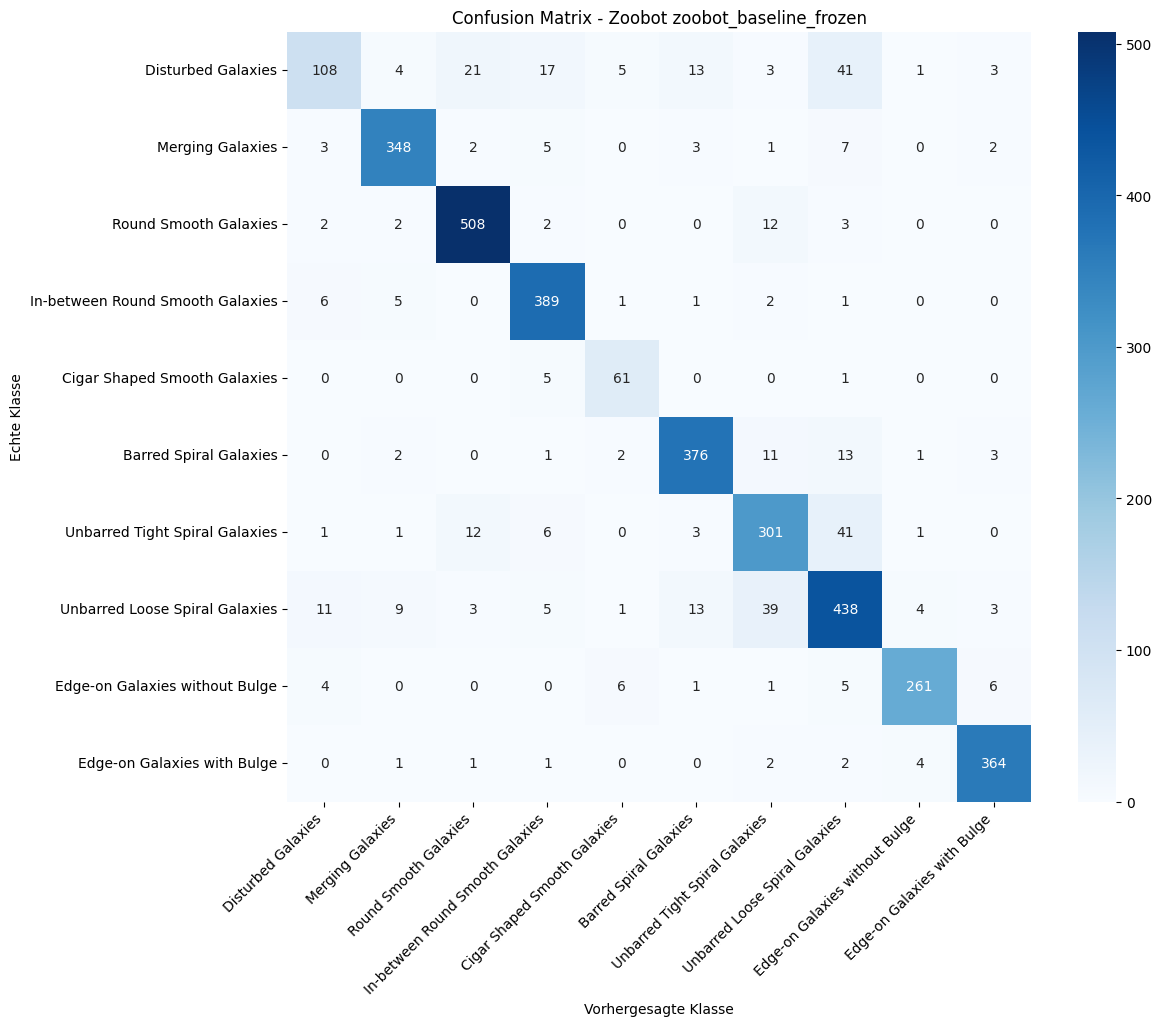

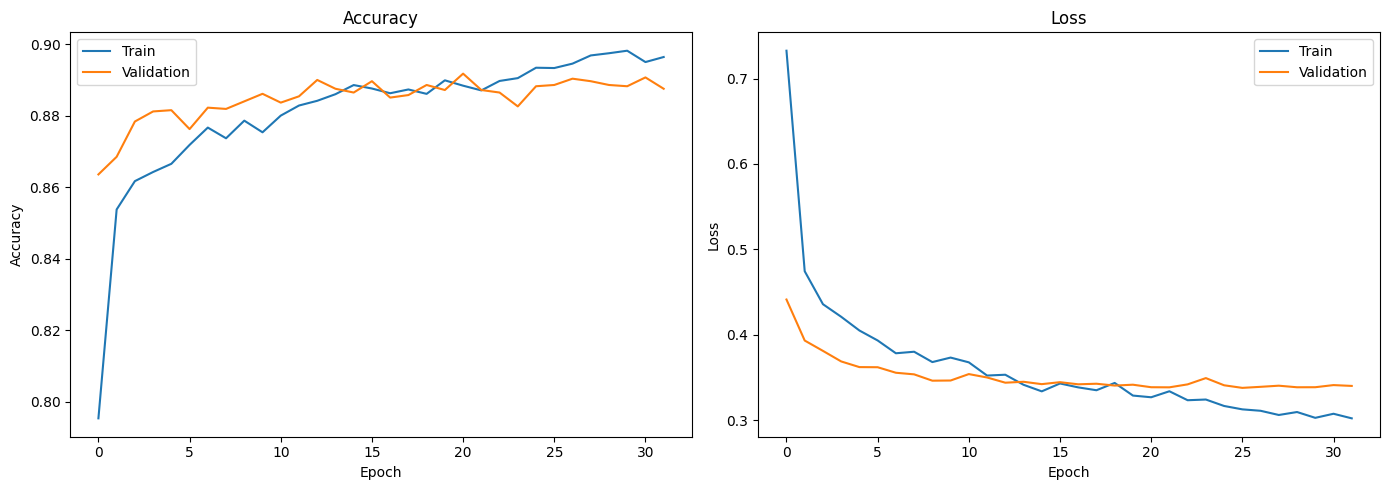

Test-Metriken gespeichert unter: ..\reports\zoobot\zoobot_baseline_frozen_test_metrics.json
Test Accuracy gespeichert unter: ..\reports\zoobot\zoobot_baseline_frozen_test_accuracy.txt
Vorhersagen gespeichert unter: ..\reports\zoobot\zoobot_baseline_frozen_test_predictions.csv
Confusion Matrix gespeichert unter: ..\reports\zoobot\zoobot_baseline_frozen_confusion_matrix.png
Trainingskurven gespeichert unter: ..\reports\zoobot\zoobot_baseline_frozen_training_curves.png
wide_bn: Test Accuracy: 0.8875 (88.75%)


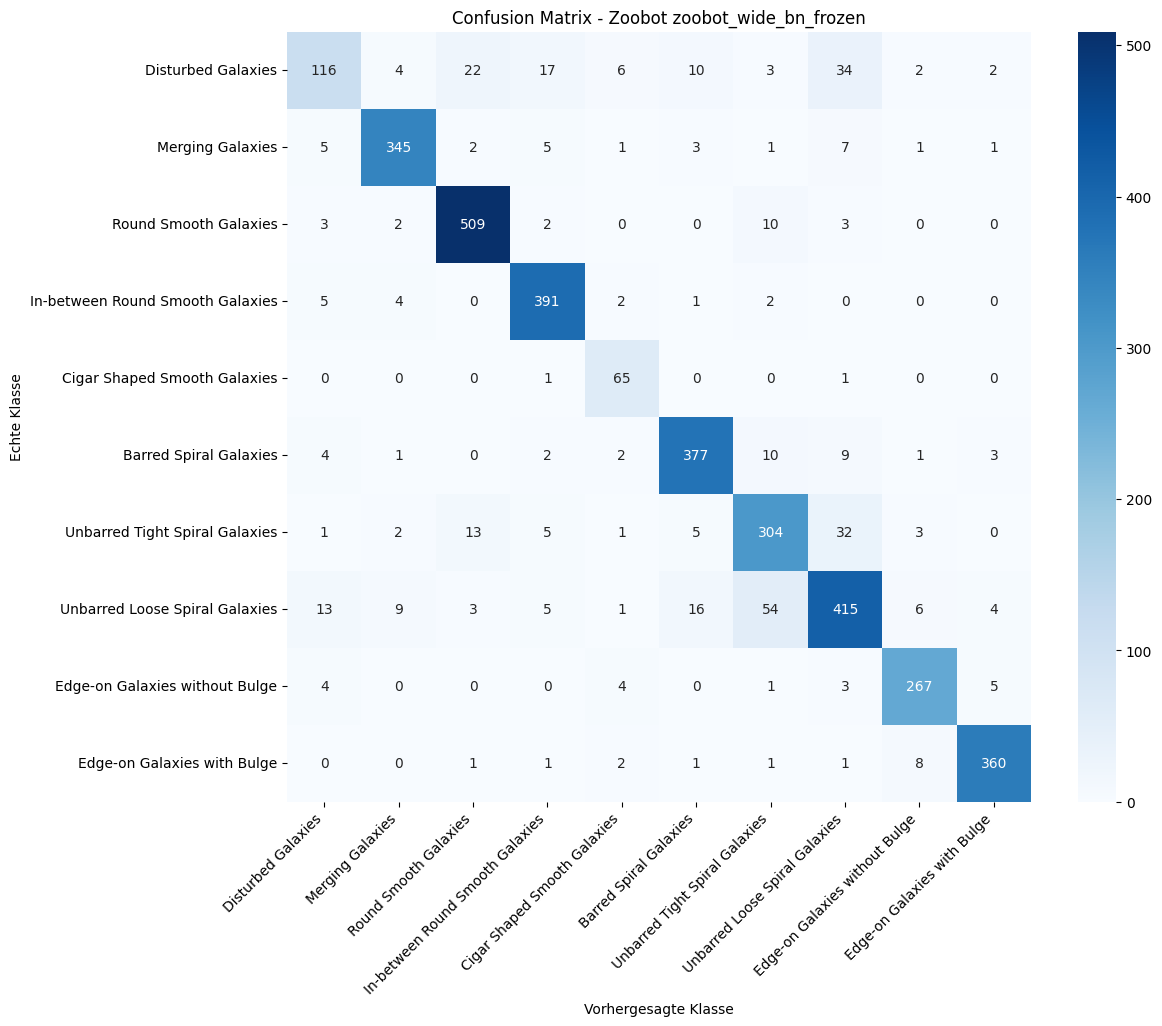

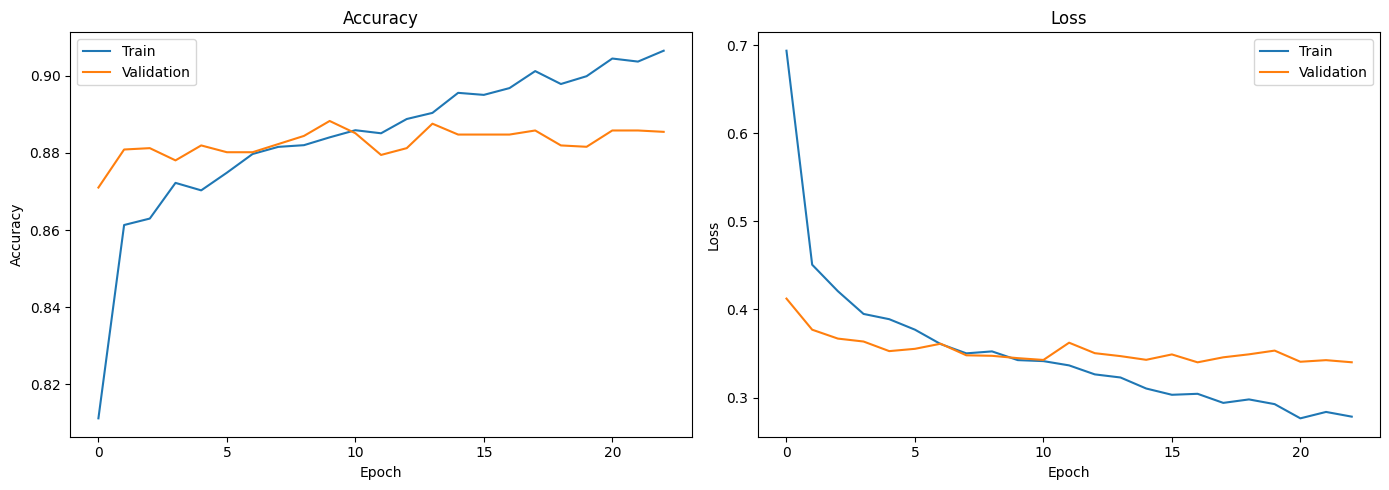

Test-Metriken gespeichert unter: ..\reports\zoobot\zoobot_wide_bn_frozen_test_metrics.json
Test Accuracy gespeichert unter: ..\reports\zoobot\zoobot_wide_bn_frozen_test_accuracy.txt
Vorhersagen gespeichert unter: ..\reports\zoobot\zoobot_wide_bn_frozen_test_predictions.csv
Confusion Matrix gespeichert unter: ..\reports\zoobot\zoobot_wide_bn_frozen_confusion_matrix.png
Trainingskurven gespeichert unter: ..\reports\zoobot\zoobot_wide_bn_frozen_training_curves.png
deep_regularized: Test Accuracy: 0.8906 (89.06%)


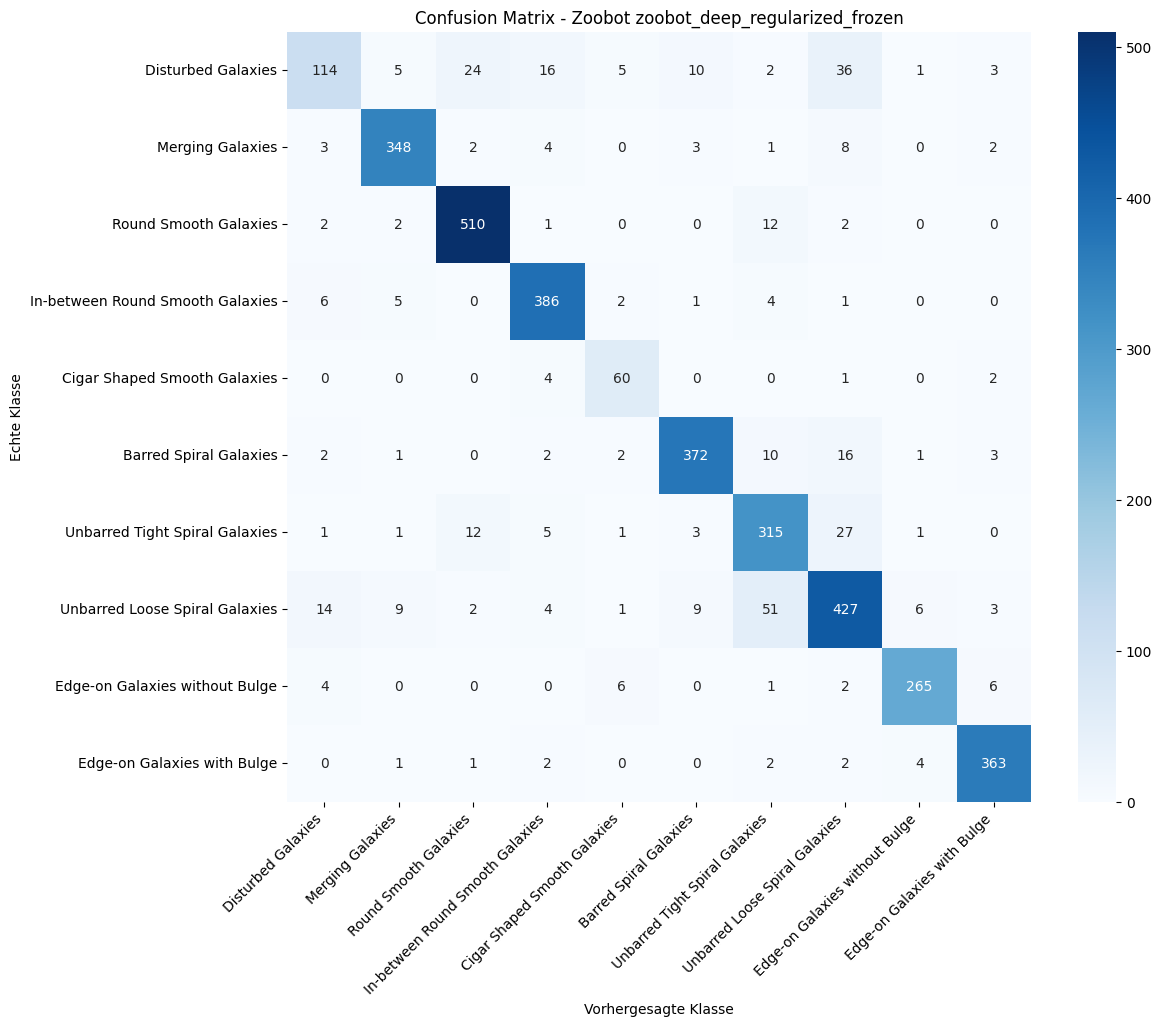

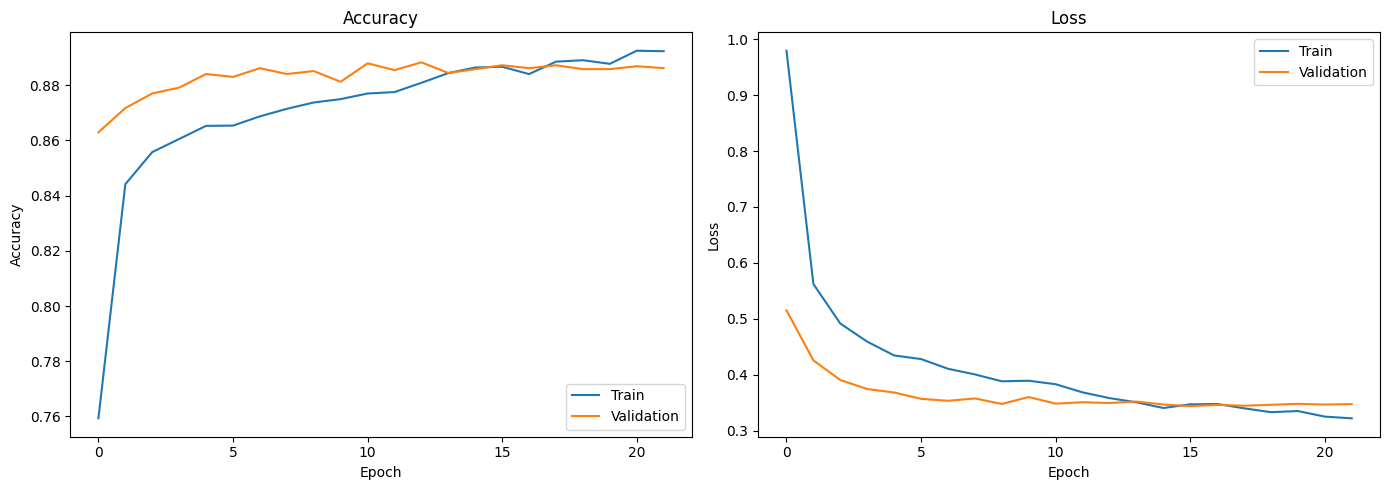

Test-Metriken gespeichert unter: ..\reports\zoobot\zoobot_deep_regularized_frozen_test_metrics.json
Test Accuracy gespeichert unter: ..\reports\zoobot\zoobot_deep_regularized_frozen_test_accuracy.txt
Vorhersagen gespeichert unter: ..\reports\zoobot\zoobot_deep_regularized_frozen_test_predictions.csv
Confusion Matrix gespeichert unter: ..\reports\zoobot\zoobot_deep_regularized_frozen_confusion_matrix.png
Trainingskurven gespeichert unter: ..\reports\zoobot\zoobot_deep_regularized_frozen_training_curves.png
layernorm_silu: Test Accuracy: 0.8816 (88.16%)


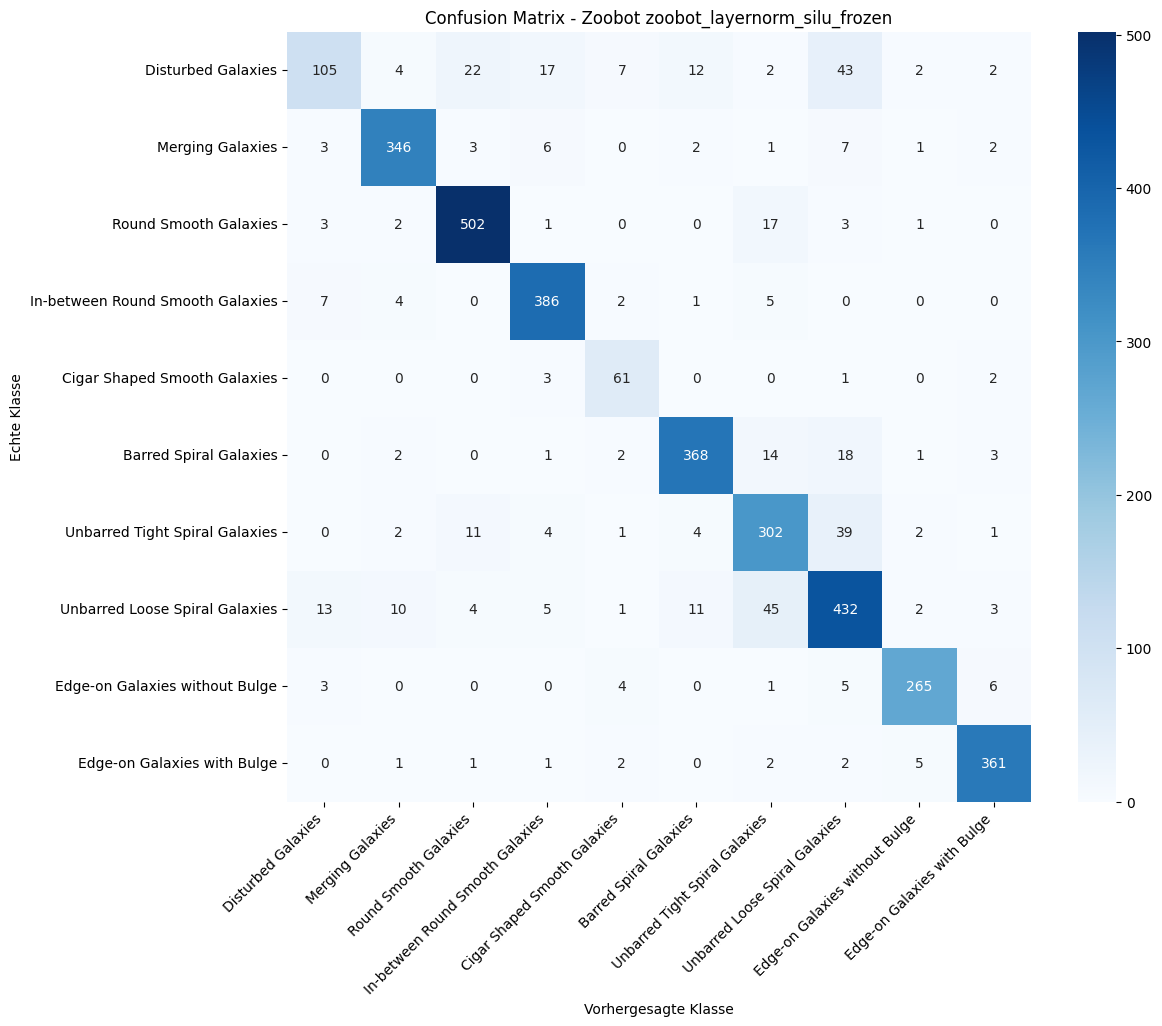

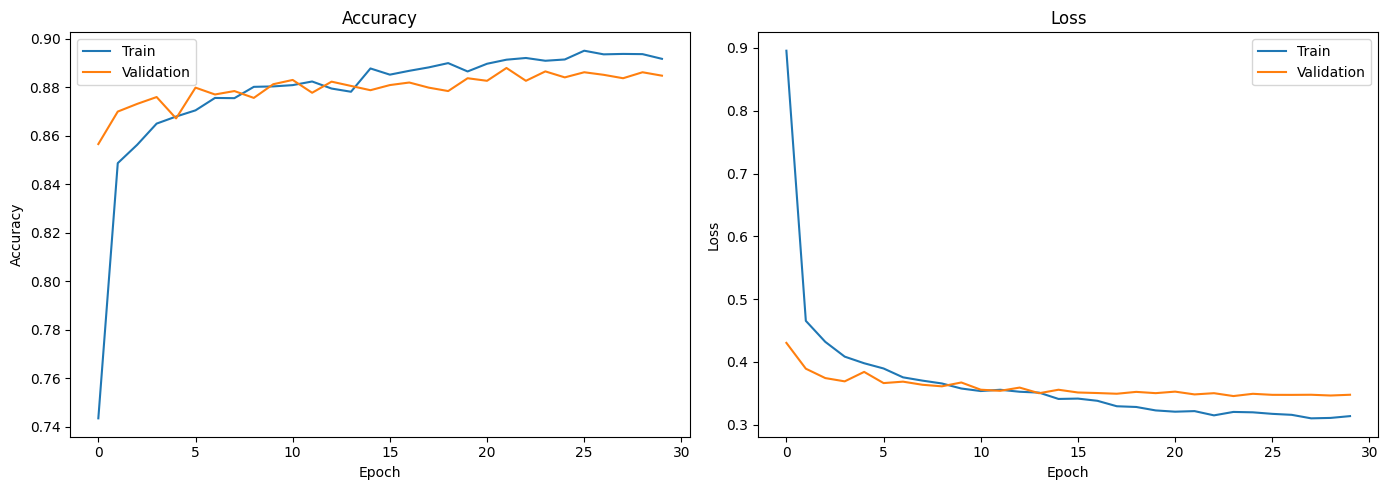

Test-Metriken gespeichert unter: ..\reports\zoobot\zoobot_layernorm_silu_frozen_test_metrics.json
Test Accuracy gespeichert unter: ..\reports\zoobot\zoobot_layernorm_silu_frozen_test_accuracy.txt
Vorhersagen gespeichert unter: ..\reports\zoobot\zoobot_layernorm_silu_frozen_test_predictions.csv
Confusion Matrix gespeichert unter: ..\reports\zoobot\zoobot_layernorm_silu_frozen_confusion_matrix.png
Trainingskurven gespeichert unter: ..\reports\zoobot\zoobot_layernorm_silu_frozen_training_curves.png


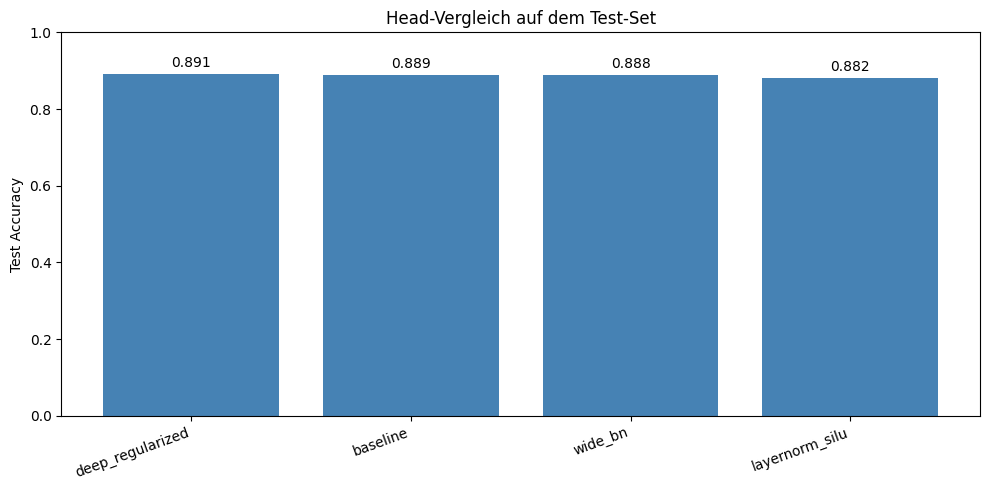

Vergleichssummary gespeichert unter: ..\reports\zoobot\head_comparison_summary.csv
Vergleichs-JSON gespeichert unter: ..\reports\zoobot\head_comparison_summary.json
Vergleichsplot gespeichert unter: ..\reports\zoobot\head_comparison_accuracy.png

Bestes Modell: zoobot_deep_regularized_frozen mit 89.06% Accuracy


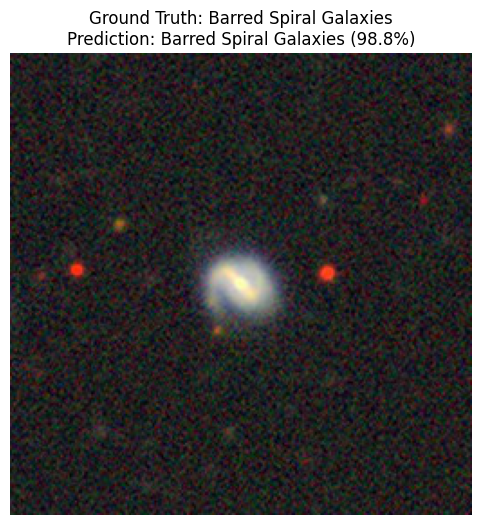

Testbild gespeichert unter: ..\reports\zoobot\zoobot_deep_regularized_frozen_test_example.png


In [ ]:
def evaluate_pytorch_model(model, test_idx, images_raw, labels, batch_size=32):
    model.eval()
    test_dataset = GalaxyDataset(images_raw, labels, test_idx, transform=None)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    accuracy = float((all_preds == all_targets).mean())

    return accuracy, all_preds, all_targets


def predict_single_image(model, image_np):
    model.eval()
    image_tensor = torch.tensor(np.transpose(image_np, (2, 0, 1)), dtype=torch.float32) / 255.0
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image_tensor)
        probabilities = torch.softmax(logits, dim=1)
        confidence, prediction = torch.max(probabilities, dim=1)

    return int(prediction.item()), float(confidence.item())


def save_training_curves(history, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history["train_acc"], label="Train")
    axes[0].plot(history["val_acc"], label="Validation")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history["train_loss"], label="Train")
    axes[1].plot(history["val_loss"], label="Validation")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def save_confusion_matrix(best_targets, best_preds, save_path, run_name):
    cm = confusion_matrix(best_targets, best_preds)
    class_names = [LABEL_DICT[i] for i in range(NUM_CLASSES)]

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"Confusion Matrix - Zoobot {run_name}")
    ax.set_ylabel("Echte Klasse")
    ax.set_xlabel("Vorhergesagte Klasse")
    plt.xticks(rotation=45, ha="right")
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def show_test_example(model, test_idx, images_raw, labels):
    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = int(rng.choice(np.asarray(test_idx)))
    image_np = images_raw[sample_idx]
    true_label_idx = int(labels[sample_idx])
    predicted_idx, confidence = predict_single_image(model, image_np)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_np)
    ax.axis("off")
    ax.set_title(
        f"Ground Truth: {LABEL_DICT[true_label_idx]}\n"
        f"Prediction: {LABEL_DICT[predicted_idx]} ({confidence * 100:.1f}%)"
    )

    plt.show()
    plt.close(fig)


print(f"\n{'*' * 50}\nTEST-EVALUIERUNG\n{'*' * 50}")
all_results = []
best_result = None

for head_variant in HEAD_VARIANTS_TO_RUN:
    model = trained_models[head_variant]
    history = trained_histories[head_variant]
    run_name = trained_run_names[head_variant]

    test_accuracy, test_preds, test_targets = evaluate_pytorch_model(model, X_test, images_raw, labels, batch_size=BATCH_SIZE)
    print(f"{head_variant}: Test Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

    metrics = {
        "run_name": run_name,
        "head_variant": head_variant,
        "use_finetuning": USE_FINETUNING,
        "test_accuracy": test_accuracy,
        "num_test_samples": int(len(X_test)),
        "num_train_samples": int(len(train_idx)),
        "num_val_samples": int(len(val_idx)),
    }

    if SAVE_ARTIFACTS:
        cm_path = REPORTS_DIR / f"{run_name}_confusion_matrix.png"
        curves_path = REPORTS_DIR / f"{run_name}_training_curves.png"

        save_confusion_matrix(test_targets, test_preds, cm_path, run_name)
        save_training_curves(history, curves_path)

        print(f"Confusion Matrix gespeichert unter: {cm_path}")
        print(f"Trainingskurven gespeichert unter: {curves_path}")

    all_results.append(metrics)
    if best_result is None or test_accuracy > best_result["test_accuracy"]:
        best_result = {
            **metrics,
            "test_preds": test_preds,
            "test_targets": test_targets,
        }

if SAVE_ARTIFACTS:
    comparison_name = build_comparison_name()
    summary_json_path = REPORTS_DIR / f"{comparison_name}.json"
    comparison_plot_path = REPORTS_DIR / f"{comparison_name}.png"

    sorted_results = sorted(all_results, key=lambda item: item["test_accuracy"], reverse=True)

    with summary_json_path.open("w", encoding="utf-8") as f:
        json.dump(sorted_results, f, indent=2)

    fig, ax = plt.subplots(figsize=(10, 5))
    labels_for_plot = [item["head_variant"] for item in sorted_results]
    accuracies_for_plot = [item["test_accuracy"] for item in sorted_results]
    bars = ax.bar(labels_for_plot, accuracies_for_plot, color="steelblue")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Test Accuracy")
    ax.set_title("Head-Vergleich auf dem Test-Set")
    ax.bar_label(bars, fmt="%.3f", padding=3)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    fig.savefig(comparison_plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Vergleichs-JSON gespeichert unter: {summary_json_path}")
    print(f"Vergleichsplot gespeichert unter: {comparison_plot_path}")

best_variant = best_result["head_variant"]
best_model = trained_models[best_variant]
best_run_name = best_result["run_name"]
print(f"\nBestes Modell: {best_run_name} mit {best_result['test_accuracy'] * 100:.2f}% Accuracy")
show_test_example(best_model, X_test, images_raw, labels)